In [12]:
import pandas as pd
import numpy as np
from CosinorPy import file_parser, cosinor, cosinor1
import matplotlib.pyplot as plt
from scipy.stats import zscore
import seaborn as sns

In [13]:
transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_4_tpm_normalized.csv",
    index_col=0,
)
rows_to_drop_expression_data = [
    "A2450525897_n01_undetermined",
    "A2449446903_n01_undetermined",
    "B250508004_n01_undetermined",
    "B2449500127_n01_undetermined",
]
transcriptome = transcriptome.drop(index=rows_to_drop_expression_data)
transcriptome = transcriptome.sort_index()


metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_4_metadata_merged_luke.csv",
    index_col=0,
)
metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)


unusable_samples = [
    "A2450525897_n01_LICRNA01_A06",
    "A2450525897_n01_LICRNA01_A08",
    "A2450525897_n01_LICRNA01_C11",
    "A2450525897_n01_LICRNA01_D11",
    "A2450525897_n01_LICRNA01_D12",
    "A2449446903_n01_LICRNA02_F01",
    "B2449500127_n01_LICRNA04_A04",
    "B2449500127_n01_LICRNA04_A06",
    "B2449500127_n01_LICRNA04_A07",
]
borderline_unusable = [
    "A2450525897_n01_LICRNA01_F03",
    "A2450525897_n01_LICRNA01_G07",
    "A2449446903_n01_LICRNA02_A04",
    "A2449446903_n01_LICRNA02_H10",
    "B2449500127_n01_LICRNA04_H02",
    "B2449500127_n01_LICRNA04_H11",
]
all_unsable = borderline_unusable + unusable_samples

trimmed_transcriptome = transcriptome.drop(index=all_unsable)
trimmed_metadata = metadata.drop(index=all_unsable)
long_term_transcriptome = trimmed_transcriptome.loc[
    trimmed_metadata["Experiment Type"] == "Long Term"
]
long_term_metadata = trimmed_metadata.loc[
    trimmed_metadata["Experiment Type"] == "Long Term"
]

circadian_transcriptome = trimmed_transcriptome.loc[
    trimmed_metadata["Experiment Type"] == "Circadian Experiment 1"
]
long_term_metadata = trimmed_metadata.loc[
    trimmed_metadata["Experiment Type"] == "Long Term"
]

circadian_metadata = trimmed_metadata.loc[
    trimmed_metadata["Experiment Type"] == "Circadian Experiment 1"
]


microbiome_abundance = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Microbiome/lic2024_16S_rab.csv"
)
merged_microbiome = microbiome_abundance.merge(
    metadata[["sampID", "Experiment Type"]], left_on="plantID", right_on="sampID"
)
circadian_microbiome = merged_microbiome.loc[
    merged_microbiome["Experiment Type"] == "Circadian Experiment 1"
]


long_term_microbiome = merged_microbiome[
    merged_microbiome["Experiment Type"] == "Long Term"
]
long_term_microbiome

total_load_df = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Microbiome/lic2024_ham_16S_ITS.csv",
    index_col=0,
)

long_term_metadata_w_load_info = long_term_metadata.merge(
    total_load_df[["ham16s", "giitsreads", "hamits"]],
    left_on="sampID",
    right_index=True,
    how="left",
)

circadian_metadata = circadian_metadata.merge(
    total_load_df[["ham16s", "giitsreads", "hamits"]],
    left_on="sampID",
    right_index=True,
    how="left",
)
defense_gene_list = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/load_correlated_defense_genes_union_GO_and_FLG.csv"
)

In [14]:
circadian_expt_1_start_time = circadian_metadata.loc[
    circadian_metadata["Experiment Type"] == "Circadian Experiment 1"
]["Date and Time"].min()
# circadian_expt_2_start_time = circadian_metadata.loc[circadian_metadata['Experiment Type'] == 'Circadian Experiment 2']['Date and Time'].min()
circadian_metadata["Time Since Start"] = (
    circadian_metadata["Date and Time"] - circadian_metadata["Date and Time"].iloc[0]
) / pd.Timedelta(hours=1)
circadian_metadata["Time Since Start"].loc[
    circadian_metadata["Experiment Type"] == "Circadian Experiment 1"
] = (
    circadian_metadata.loc[
        circadian_metadata["Experiment Type"] == "Circadian Experiment 1"
    ]["Date and Time"]
    - circadian_expt_1_start_time
) / pd.Timedelta(
    hours=1
)
# circadian_metadata['Time Since Start'].loc[circadian_metadata['Experiment Type'] == 'Circadian Experiment 2'] = (circadian_metadata.loc[circadian_metadata['Experiment Type'] == 'Circadian Experiment 2']['Date and Time'] - circadian_expt_2_start_time)/pd.Timedelta(hours=1)

/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_93997/1716288078.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  circadian_metadata["Time Since Start"].loc[
/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_93997/1716

In [15]:
circadian_metadata["Time Since Start"].unique()

array([ 0.,  4.,  8., 12., 16., 20., 24., 28., 32., 36., 40., 44., 48.])

In [16]:
circadian_metadata

,plate.pos,sampID,sample.type,timepoint,date,time,extractplate,rnaprepplate,Unmapped,No Feature,...,plate_col,Total Reads,Experiment Type,Sample Month,daysincestart,Date and Time,ham16s,giitsreads,hamits,Time Since Start
filename,,,,,,,,,,,,,,,,,,,,,
B250508004_n01_LICRNA03_A05,A05,LIC385,plant,c1_t01,2/9/24,20:00,LICCIRC_01,LICRNA_03,964260.0,92653.0,...,5,1966537.0,Circadian Experiment 1,February,100,2024-02-09 20:00:00,0.052164,40308.0,0.570333,0.0
B250508004_n01_LICRNA03_B05,B05,LIC386,plant,c1_t01,2/9/24,20:00,LICCIRC_01,LICRNA_03,2693674.0,455337.0,...,5,6397701.0,Circadian Experiment 1,February,100,2024-02-09 20:00:00,0.048232,45085.0,0.932638,0.0
B250508004_n01_LICRNA03_C05,C05,LIC387,plant,c1_t01,2/9/24,20:00,LICCIRC_01,LICRNA_03,3797944.0,492504.0,...,5,7034134.0,Circadian Experiment 1,February,100,2024-02-09 20:00:00,0.090157,37650.0,0.985817,0.0
B250508004_n01_LICRNA03_D05,D05,LIC388,plant,c1_t01,2/9/24,20:00,LICCIRC_01,LICRNA_03,1870339.0,300743.0,...,5,5076681.0,Circadian Experiment 1,February,100,2024-02-09 20:00:00,0.083026,35583.0,0.850013,0.0
B250508004_n01_LICRNA03_E05,E05,LIC389,plant,c1_t01,2/9/24,20:00,LICCIRC_01,LICRNA_03,1794713.0,412096.0,...,5,6382330.0,Circadian Experiment 1,February,100,2024-02-09 20:00:00,0.066437,45351.0,0.765363,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B2449500127_n01_LICRNA04_D06,D06,LIC544,plant,c1_t13,2/11/24,20:00,LICCIRC_02,LICRNA_04,1368939.0,139401.0,...,6,2885051.0,Circadian Experiment 1,February,102,2024-02-11 20:00:00,0.076878,28171.0,3.949239,48.0
B2449500127_n01_LICRNA04_E06,E06,LIC545,plant,c1_t13,2/11/24,20:00,LICCIRC_02,LICRNA_04,2970240.0,317492.0,...,6,5995498.0,Circadian Experiment 1,February,102,2024-02-11 20:00:00,0.106202,28579.0,3.460093,48.0
B2449500127_n01_LICRNA04_F06,F06,LIC546,plant,c1_t13,2/11/24,20:00,LICCIRC_02,LICRNA_04,1373071.0,172269.0,...,6,3506956.0,Circadian Experiment 1,February,102,2024-02-11 20:00:00,0.101674,25562.0,2.557938,48.0


In [17]:
transcriptome_in_defense_gene_list = circadian_transcriptome.loc[
    :, circadian_transcriptome.columns.isin(defense_gene_list["gene"])
]
summed_zscored_transcriptome = (
    transcriptome_in_defense_gene_list.apply(zscore).sum(axis=1) / 199
)
circadian_metadata_w_load_info = circadian_metadata.merge(
    summed_zscored_transcriptome.rename("Summed Defense Z Score"),
    left_index=True,
    right_index=True,
)

In [18]:
plotting_circadian = circadian_metadata_w_load_info[
    ["timepoint", "Summed Defense Z Score", "Time Since Start"]
]
plotting_circadian["Run"] = "Circadian Run 1"
plotting_circadian

/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_93997/2262843182.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plotting_circadian["Run"] = "Circadian Run 1"


,timepoint,Summed Defense Z Score,Time Since Start,Run
B250508004_n01_LICRNA03_A05,c1_t01,0.578723,0.0,Circadian Run 1
B250508004_n01_LICRNA03_B05,c1_t01,-0.094438,0.0,Circadian Run 1
B250508004_n01_LICRNA03_C05,c1_t01,-0.014285,0.0,Circadian Run 1
B250508004_n01_LICRNA03_D05,c1_t01,0.428561,0.0,Circadian Run 1
B250508004_n01_LICRNA03_E05,c1_t01,-0.404812,0.0,Circadian Run 1
...,...,...,...,...
B2449500127_n01_LICRNA04_D06,c1_t13,0.587697,48.0,Circadian Run 1
B2449500127_n01_LICRNA04_E06,c1_t13,0.314456,48.0,Circadian Run 1
B2449500127_n01_LICRNA04_F06,c1_t13,0.896774,48.0,Circadian Run 1
B2449500127_n01_LICRNA04_G06,c1_t13,-0.245144,48.0,Circadian Run 1


In [19]:
plotting_circadian.to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/For_talk/plotting_circadian.csv",
    index=True,
)

In [20]:
timepoint_formatted_for_cosinor = plotting_circadian.rename(
    columns={"Time Since Start": "x", "Summed Defense Z Score": "y", "Run": "test"}
)
timepoint_formatted_for_cosinor = timepoint_formatted_for_cosinor[["x", "y", "test"]]
timepoint_formatted_for_cosinor

,x,y,test
B250508004_n01_LICRNA03_A05,0.0,0.578723,Circadian Run 1
B250508004_n01_LICRNA03_B05,0.0,-0.094438,Circadian Run 1
B250508004_n01_LICRNA03_C05,0.0,-0.014285,Circadian Run 1
B250508004_n01_LICRNA03_D05,0.0,0.428561,Circadian Run 1
B250508004_n01_LICRNA03_E05,0.0,-0.404812,Circadian Run 1
...,...,...,...
B2449500127_n01_LICRNA04_D06,48.0,0.587697,Circadian Run 1
B2449500127_n01_LICRNA04_E06,48.0,0.314456,Circadian Run 1
B2449500127_n01_LICRNA04_F06,48.0,0.896774,Circadian Run 1
B2449500127_n01_LICRNA04_G06,48.0,-0.245144,Circadian Run 1


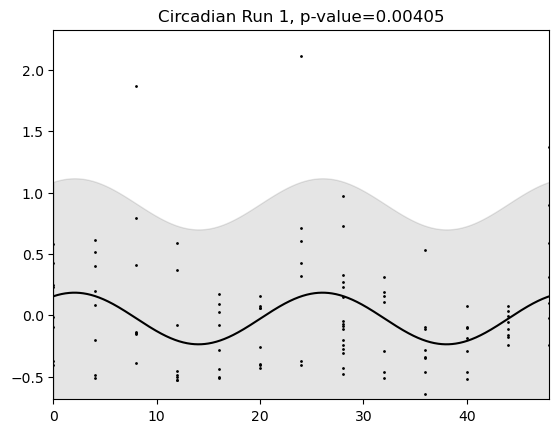

In [21]:
cosinor_results = cosinor1.fit_group(timepoint_formatted_for_cosinor, period=[24])

<Axes: xlabel='Time Since Start', ylabel='Summed Defense Z Score'>

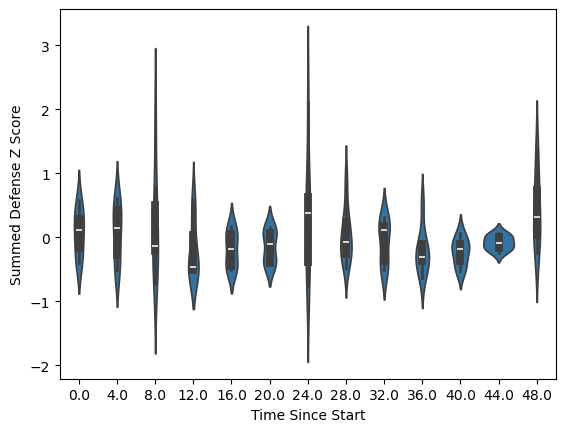

In [22]:
sns.violinplot(
    data=plotting_circadian,
    x="Time Since Start",
    y="Summed Defense Z Score",
)

<Axes: xlabel='x', ylabel='y'>

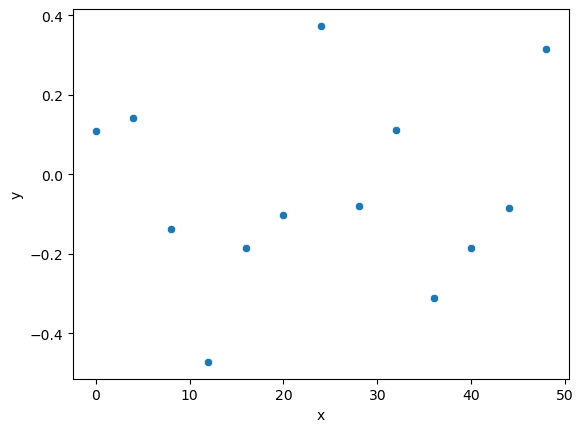

In [23]:
sns.scatterplot(
    data=timepoint_formatted_for_cosinor[["x", "y"]].groupby("x").median(), x="x", y="y"
)

In [34]:
from scipy.stats import pearsonr

circadian_plotting = circadian_metadata_w_load_info[
    ["timepoint", "time", "ham16s", "Summed Defense Z Score"]
].copy()

# Z-score ham16s across all circadian samples (keep NaN in place)
circadian_plotting["ham16s_zscore"] = zscore(
    circadian_plotting["ham16s"], nan_policy="omit"
)

# Rank across all circadian samples
circadian_plotting["Rank All Samples"] = circadian_plotting["ham16s"].rank()

# Rank within each timepoint
circadian_plotting["Rank Within Timepoint"] = circadian_plotting.groupby("timepoint")[
    "ham16s"
].rank()

# Rank within each time-of-day
circadian_plotting["Rank Within Time"] = circadian_plotting.groupby("time")[
    "ham16s"
].rank()

circadian_plotting

,timepoint,time,ham16s,Summed Defense Z Score,ham16s_zscore,Rank All Samples,Rank Within Timepoint,Rank Within Time
B250508004_n01_LICRNA03_A05,c1_t01,20:00,0.052164,0.578723,-1.299368,7.0,2.0,5.0
B250508004_n01_LICRNA03_B05,c1_t01,20:00,0.048232,-0.094438,-1.488245,3.0,1.0,2.0
B250508004_n01_LICRNA03_C05,c1_t01,20:00,0.090157,-0.014285,0.525676,84.0,6.0,19.0
B250508004_n01_LICRNA03_D05,c1_t01,20:00,0.083026,0.428561,0.183138,68.0,5.0,16.0
B250508004_n01_LICRNA03_E05,c1_t01,20:00,0.066437,-0.404812,-0.613734,27.0,4.0,10.0
...,...,...,...,...,...,...,...,...
B2449500127_n01_LICRNA04_D06,c1_t13,20:00,0.076878,0.587697,-0.112199,56.0,4.0,14.0
B2449500127_n01_LICRNA04_E06,c1_t13,20:00,0.106202,0.314456,1.296448,99.0,7.0,23.0
B2449500127_n01_LICRNA04_F06,c1_t13,20:00,0.101674,0.896774,1.078916,94.0,6.0,21.0
B2449500127_n01_LICRNA04_G06,c1_t13,20:00,0.068724,-0.245144,-0.503901,35.0,2.0,12.0


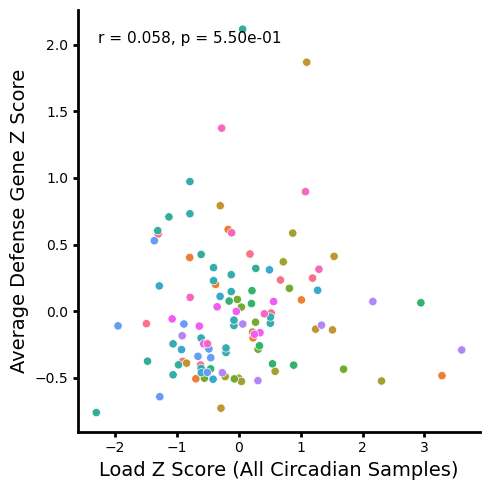

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
sns.scatterplot(
    data=circadian_plotting,
    x="ham16s_zscore",
    y="Summed Defense Z Score",
    hue="timepoint",
    ax=ax,
)
_valid = circadian_plotting[["ham16s_zscore", "Summed Defense Z Score"]].dropna()
r, p = pearsonr(_valid["ham16s_zscore"], _valid["Summed Defense Z Score"])
ax.text(
    0.05,
    0.95,
    f"r = {r:.3f}, R² = {r**2:.3f}, p = {p:.2e}",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
)
plt.xlabel("Load Z Score (All Circadian Samples)", fontsize=14)
plt.ylabel("Average Defense Gene Z Score", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.get_legend().remove()
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

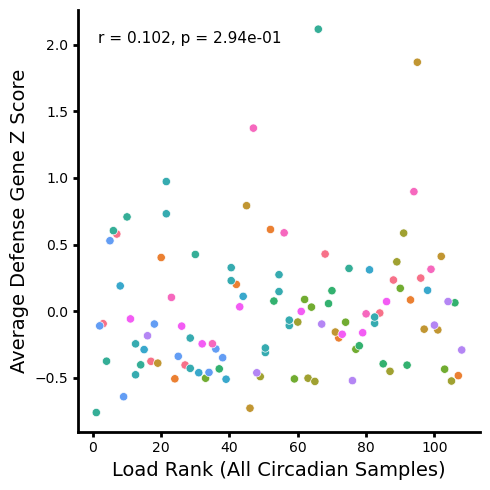

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
sns.scatterplot(
    data=circadian_plotting,
    x="Rank All Samples",
    y="Summed Defense Z Score",
    hue="timepoint",
    ax=ax,
)
_valid = circadian_plotting[["Rank All Samples", "Summed Defense Z Score"]].dropna()
r, p = pearsonr(_valid["Rank All Samples"], _valid["Summed Defense Z Score"])
ax.text(
    0.05,
    0.95,
    f"r = {r:.3f}, R² = {r**2:.3f}, p = {p:.2e}",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
)
plt.xlabel("Load Rank (All Circadian Samples)", fontsize=14)
plt.ylabel("Average Defense Gene Z Score", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.get_legend().remove()
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

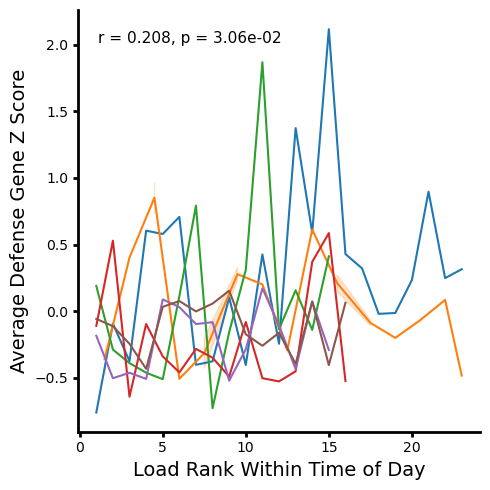

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
sns.lineplot(
    data=circadian_plotting,
    x="Rank Within Time",
    y="Summed Defense Z Score",
    hue="time",
    ax=ax,
)
_valid = circadian_plotting[["Rank Within Time", "Summed Defense Z Score"]].dropna()
r, p = pearsonr(_valid["Rank Within Time"], _valid["Summed Defense Z Score"])
ax.text(
    0.05,
    0.95,
    f"r = {r:.3f}, R² = {r**2:.3f}, p = {p:.2e}",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
)
plt.xlabel("Load Rank Within Time of Day", fontsize=14)
plt.ylabel("Average Defense Gene Z Score", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.get_legend().remove()
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

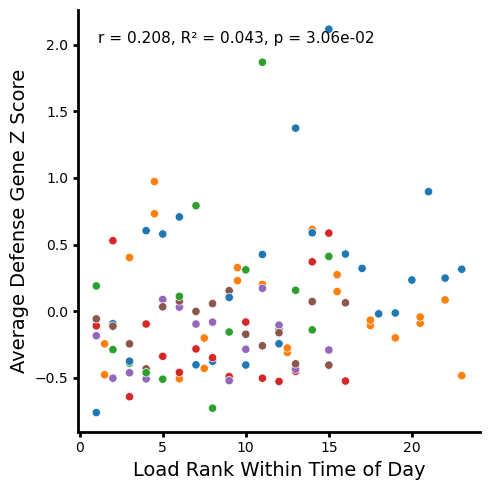

In [39]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
sns.scatterplot(
    data=circadian_plotting,
    x="Rank Within Time",
    y="Summed Defense Z Score",
    hue="time",
    ax=ax,
)
_valid = circadian_plotting[["Rank Within Time", "Summed Defense Z Score"]].dropna()
r, p = pearsonr(_valid["Rank Within Time"], _valid["Summed Defense Z Score"])
ax.text(
    0.05,
    0.95,
    f"r = {r:.3f}, R² = {r**2:.3f}, p = {p:.2e}",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
)
plt.xlabel("Load Rank Within Time of Day", fontsize=14)
plt.ylabel("Average Defense Gene Z Score", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.get_legend().remove()
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

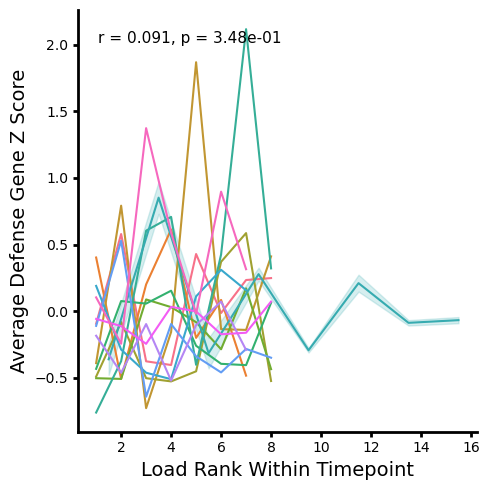

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
sns.lineplot(
    data=circadian_plotting,
    x="Rank Within Timepoint",
    y="Summed Defense Z Score",
    hue="timepoint",
    ax=ax,
)
_valid = circadian_plotting[
    ["Rank Within Timepoint", "Summed Defense Z Score"]
].dropna()
r, p = pearsonr(_valid["Rank Within Timepoint"], _valid["Summed Defense Z Score"])
ax.text(
    0.05,
    0.95,
    f"r = {r:.3f}, R² = {r**2:.3f}, p = {p:.2e}",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
)
plt.xlabel("Load Rank Within Timepoint", fontsize=14)
plt.ylabel("Average Defense Gene Z Score", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.get_legend().remove()
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

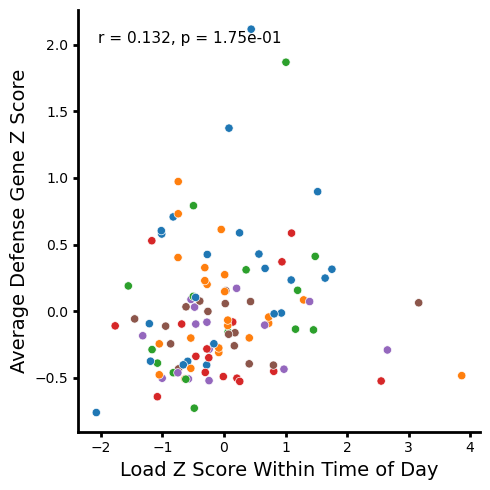

In [ ]:
circadian_plotting["ham16s_zscore_within_time"] = circadian_plotting.groupby("time")[
    "ham16s"
].transform(lambda x: zscore(x, nan_policy="omit"))

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
sns.scatterplot(
    data=circadian_plotting,
    x="ham16s_zscore_within_time",
    y="Summed Defense Z Score",
    hue="time",
    ax=ax,
)
_valid = circadian_plotting[
    ["ham16s_zscore_within_time", "Summed Defense Z Score"]
].dropna()
r, p = pearsonr(_valid["ham16s_zscore_within_time"], _valid["Summed Defense Z Score"])
ax.text(
    0.05,
    0.95,
    f"r = {r:.3f}, R² = {r**2:.3f}, p = {p:.2e}",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
)
plt.xlabel("Load Z Score Within Time of Day", fontsize=14)
plt.ylabel("Average Defense Gene Z Score", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.get_legend().remove()
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()